In [4]:
import pandas as pd 
df = pd.read_csv(r"heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [6]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\ayoub\Downloads\heart.csv")
from sklearn.model_selection import train_test_split

x =  df.drop(columns=['target']) 
y = df['target']

X_train , X_test , y_train , y_test = train_test_split(x , y ,test_size=0.2,random_state=42)
print("Taille du dataset d'entrainement :",X_train.shape)
print("Taille du dataset de test :",X_test.shape)

Taille du dataset d'entrainement : (820, 13)
Taille du dataset de test : (205, 13)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)


logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train,y_train)

y_pred = logreg.predict(X_test)

print("Precision du model : ",accuracy_score(y_test , y_pred))
print("Rapport de classification :\n", classification_report(y_test,y_pred))

Precision du model :  0.7902439024390244
Rapport de classification :
               precision    recall  f1-score   support

           0       0.86      0.70      0.77       102
           1       0.75      0.88      0.81       103

    accuracy                           0.79       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.79      0.79       205



In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier (n_estimators=100, max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)
print("Precision du modele :", accuracy_score (y_test, y_pred_rf))
print("Rapport de classification:\n", classification_report(y_test,y_pred_rf))

Precision du modele : 0.8536585365853658
Rapport de classification:
               precision    recall  f1-score   support

           0       0.90      0.79      0.84       102
           1       0.82      0.91      0.86       103

    accuracy                           0.85       205
   macro avg       0.86      0.85      0.85       205
weighted avg       0.86      0.85      0.85       205



[[71 31]
 [12 91]]


<function matplotlib.pyplot.show(close=None, block=None)>

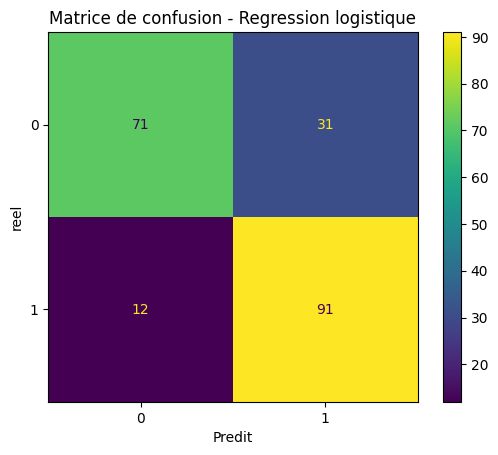

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_predictions (y_test, y_pred)
plt.xlabel("Predit")
plt.ylabel("reel")
plt.title("Matrice de confusion - Regression logistique")
plt.show